# Ingestion-Accuracy Report — *Test_ch4-5.pdf*

**Goal.** Quantify how faithfully the marking-tools pipeline *reads and ingests*
an OpenStax statistics textbook (chapters 4–5, 75 pages) into MongoDB.

This notebook compares **ground truth** extracted directly from the PDF text/vector
layer (via PyMuPDF) against the **ingested artefacts** stored in MongoDB
(`pdf_chunks`, `book_exercises`, `questions`, and the math/table/figure indexes),
then derives a set of **accuracy metrics** and charts.

> **Data-driven.** Every number below is computed at run time from
> `Book/Test_ch4-5.pdf` and the JSON dumps in `report/data/` produced by
> `scripts/export_ingestion_metrics.py`. Nothing is hard-coded.
>
> **Partial-ingestion safe.** Ingestion may still be running when this runs. The
> notebook degrades gracefully (empty collections → 0 / N-A) and is meant to be
> *re-run* after `export_ingestion_metrics.py` once ingestion completes.


## 0. Setup & data loading

In [1]:

import json, re
from pathlib import Path
import matplotlib.pyplot as plt

# Resolve repo root whether the notebook runs from report/ or repo root.
HERE = Path.cwd()
REPO = HERE
for cand in (HERE, HERE.parent, HERE.parent.parent):
    if (cand / "Book" / "Test_ch4-5.pdf").exists():
        REPO = cand
        break
DATA = REPO / "report" / "data"
PDF_PATH = REPO / "Book" / "Test_ch4-5.pdf"
print("REPO:", REPO)
print("PDF exists:", PDF_PATH.exists())
print("DATA exists:", DATA.exists())

def load(name, default):
    p = DATA / name
    if not p.exists():
        print(f"  ! missing {name}, using default")
        return default
    return json.loads(p.read_text())

chunks    = load("pdf_chunks.json", [])
exercises = load("book_exercises.json", [])
questions = load("questions.json", [])
counts    = load("index_counts.json", {})
meta      = load("_meta.json", {})

EXPECTED_CHAPTERS = meta.get("expected_chapters", [4, 5])
print(f"\nLoaded: {len(chunks)} chunks, {len(exercises)} exercises, "
      f"{len(questions)} questions")
print("Index counts:", counts)
print("Export transport:", meta.get("transport"), "| exported_at:", meta.get("exported_at"))


REPO: /Users/ankurbatta/Documents/GitHub/marking-tools
PDF exists: True
DATA exists: True

Loaded: 132 chunks, 38 exercises, 5 questions
Index counts: {'pdf_chunks': 132, 'book_exercises': 38, 'questions': 5, 'math_index': 286, 'table_index': 7, 'figure_index': 76}
Export transport: pymongo | exported_at: 2026-06-23T09:01:03.426841+00:00


## A. Ground truth — read straight from the PDF

We open `Test_ch4-5.pdf` with **PyMuPDF** and measure the *raw* document so we have
an independent reference to compare ingestion against:

* **Pages** — `doc.page_count`.
* **Structural markers in the text layer** via regex:
  * `Example 4.12` style headers (`Example \d+\.\d+`)
  * the word `Solution`
  * numbered exercises (line-leading `\d+\.` at the start of a line)
* **Embedded raster images** — `page.get_images()`.
* **Vector-graphic regions** — `page.get_drawings()` (charts, boxes, plots).
* **Detected tables** — `page.find_tables()`.

> **Important caveat — OpenStax "Try It" boxes.** In OpenStax PDFs the *Try It*
> practice boxes are rendered as **vector-drawn graphics**, not selectable text.
> A text-layer regex therefore **under-counts** them. Treat any "Try It" recall
> figure below as **approximate / a lower bound**.


In [2]:

import fitz  # PyMuPDF

doc = fitz.open(str(PDF_PATH))
gt_pages = doc.page_count

full_text_parts = []
gt_images = 0
gt_drawings = 0
gt_tables = 0
per_page = []

for page in doc:
    txt = page.get_text("text")
    full_text_parts.append(txt)
    n_img = len(page.get_images(full=True))
    n_draw = len(page.get_drawings())
    try:
        n_tab = len(page.find_tables().tables)
    except Exception:
        n_tab = 0
    gt_images += n_img
    gt_drawings += n_draw
    gt_tables += n_tab
    per_page.append({"page": page.number + 1, "images": n_img,
                     "drawings": n_draw, "tables": n_tab, "chars": len(txt)})

full_text = "\n".join(full_text_parts)
doc.close()

# Structural markers (text layer)
gt_examples   = len(re.findall(r"Example\s+\d+\.\d+", full_text))
gt_solutions  = len(re.findall(r"\bSolution\b", full_text))
gt_try_it     = len(re.findall(r"\bTry\s*It\b", full_text))   # lower bound (vector boxes)
# numbered exercises: lines that start with "<n>." (allow leading spaces)
gt_num_exercises = len(re.findall(r"(?m)^\s*\d{1,3}\.\s", full_text))

ground_truth = {
    "pages": gt_pages,
    "examples": gt_examples,
    "solutions": gt_solutions,
    "try_it_textlayer": gt_try_it,
    "numbered_exercises": gt_num_exercises,
    "embedded_images": gt_images,
    "vector_drawing_regions": gt_drawings,
    "detected_tables": gt_tables,
}
print("GROUND TRUTH (from PDF):")
for k, v in ground_truth.items():
    print(f"  {k:24s}: {v}")


GROUND TRUTH (from PDF):
  pages                   : 75
  examples                : 30
  solutions               : 35
  try_it_textlayer        : 0
  numbered_exercises      : 239
  embedded_images         : 43
  vector_drawing_regions  : 889
  detected_tables         : 23


## B. Ingested metrics — what made it into MongoDB

Computed from the `report/data/*.json` dumps (metadata only; embeddings are
represented by a presence flag + dimension, never the raw vectors).


In [3]:

def pct(num, den):
    return (100.0 * num / den) if den else 0.0

# ---- pdf_chunks ----
n_chunks = len(chunks)
chapters_detected = sorted({c.get("chapter_num") for c in chunks if c.get("chapter_num") is not None})

covered_pages = set()
for c in chunks:
    ps, pe = c.get("page_start"), c.get("page_end")
    if ps is None:
        continue
    if pe is None or pe < ps:
        pe = ps
    if pe - ps > 60:        # clamp end-flush artefacts
        pe = ps
    covered_pages.update(range(ps, pe + 1))
n_pages_covered = len(covered_pages)

n_emb = sum(1 for c in chunks if c.get("embedding_present"))
emb_dims = sorted({c.get("embedding_dim") for c in chunks if c.get("embedding_present")})
n_chunks_math  = sum(1 for c in chunks if c.get("has_math") or c.get("has_formula") or c.get("math_text_len", 0) > 0)
n_chunks_table = sum(1 for c in chunks if c.get("has_tables") or c.get("table_texts_count", 0) > 0)
n_chunks_image = sum(1 for c in chunks if c.get("has_images") or c.get("image_texts_count", 0) > 0)
n_chunks_example = sum(1 for c in chunks if c.get("has_example"))

# ---- book_exercises ----
from collections import Counter
ex_kind = Counter(e.get("exercise_kind") for e in exercises)
n_examples_mined = ex_kind.get("example", 0)
n_try_it_mined   = ex_kind.get("try_it", 0)
n_homework_mined = ex_kind.get("homework", 0)
n_ex_math   = sum(1 for e in exercises if e.get("has_math_text"))
n_ex_table  = sum(1 for e in exercises if e.get("has_table_markdown"))
n_ex_figure = sum(1 for e in exercises if e.get("has_figure_desc"))
n_ex_enriched = sum(1 for e in exercises
                    if e.get("has_math_text") or e.get("has_table_markdown") or e.get("has_figure_desc"))

# ---- questions (generated) ----
q_diff  = Counter((q.get("difficulty") or "unknown") for q in questions)
q_bloom = Counter((q.get("bloom_level") or "unknown") for q in questions)
q_chap  = Counter(q.get("chapter_num") for q in questions)

# ---- index sizes ----
math_idx   = counts.get("math_index", 0)
table_idx  = counts.get("table_index", 0)
figure_idx = counts.get("figure_index", 0)

ingested = {
    "chunks": n_chunks,
    "pages_covered": n_pages_covered,
    "chapters_detected": chapters_detected,
    "chunks_with_embedding": n_emb,
    "embedding_dims": emb_dims,
    "chunks_with_math": n_chunks_math,
    "chunks_with_table": n_chunks_table,
    "chunks_with_image": n_chunks_image,
    "chunks_with_example_flag": n_chunks_example,
    "exercises_total": len(exercises),
    "examples_mined": n_examples_mined,
    "try_it_mined": n_try_it_mined,
    "homework_mined": n_homework_mined,
    "exercises_with_math": n_ex_math,
    "exercises_with_table": n_ex_table,
    "exercises_with_figure": n_ex_figure,
    "exercises_enriched": n_ex_enriched,
    "math_index": math_idx, "table_index": table_idx, "figure_index": figure_idx,
}
print("INGESTED METRICS:")
for k, v in ingested.items():
    print(f"  {k:26s}: {v}")


INGESTED METRICS:
  chunks                    : 132
  pages_covered             : 66
  chapters_detected         : [4, 5]
  chunks_with_embedding     : 132
  embedding_dims            : [768]
  chunks_with_math          : 116
  chunks_with_table         : 5
  chunks_with_image         : 35
  chunks_with_example_flag  : 33
  exercises_total           : 38
  examples_mined            : 29
  try_it_mined              : 5
  homework_mined            : 2
  exercises_with_math       : 32
  exercises_with_table      : 2
  exercises_with_figure     : 8
  exercises_enriched        : 33
  math_index                : 286
  table_index               : 7
  figure_index              : 76


## C. Accuracy metrics — ground truth vs. ingested

Each metric is computed from the values above. Where a metric cannot be exactly
grounded against the PDF, it is **explicitly labelled as an estimate**.


In [4]:

# Page coverage — exact (we know GT page count).
page_coverage_pct = pct(n_pages_covered, ground_truth["pages"])

# Chapter detection — exact (expected = len(EXPECTED_CHAPTERS)).
n_expected_chapters = len(EXPECTED_CHAPTERS)
chapters_match = sorted(set(chapters_detected)) == sorted(set(EXPECTED_CHAPTERS))
chapter_detection_pct = pct(len(set(chapters_detected) & set(EXPECTED_CHAPTERS)),
                            n_expected_chapters)

# Example recall — examples_mined / examples_in_pdf  (exact-ish; GT from text layer).
example_recall_pct = pct(n_examples_mined, ground_truth["examples"])

# Try-It recall — ESTIMATE only (GT under-counts vector boxes).
try_it_recall_pct = pct(n_try_it_mined, ground_truth["try_it_textlayer"]) \
    if ground_truth["try_it_textlayer"] else None

# Numbered-exercise capture — ESTIMATE (homework mining vs text-layer numbered lines).
exercise_capture_pct = pct(n_homework_mined, ground_truth["numbered_exercises"]) \
    if ground_truth["numbered_exercises"] else None

# Math-bearing chunk rate — share of chunks carrying maths.
math_chunk_rate_pct = pct(n_chunks_math, n_chunks)

# Table capture — detected tables that became table-index entries (ESTIMATE: index
# may dedupe/merge, so >100% or <100% are both plausible).
table_capture_pct = pct(table_idx, ground_truth["detected_tables"]) \
    if ground_truth["detected_tables"] else None

# Figure capture — figure-index entries vs embedded raster images (ESTIMATE: many
# figures are vector drawings, not raster images, so this is a rough proxy).
figure_capture_pct = pct(figure_idx, ground_truth["embedded_images"]) \
    if ground_truth["embedded_images"] else None

# Embedding coverage — exact.
embedding_coverage_pct = pct(n_emb, n_chunks)

# Exercise content-enrichment rate — exact (share of mined exercises carrying
# math/table/figure context).
enrichment_pct = pct(n_ex_enriched, len(exercises)) if exercises else None

accuracy = {
    "page_coverage_pct":        round(page_coverage_pct, 1),
    "chapter_detection_pct":    round(chapter_detection_pct, 1),
    "example_recall_pct":       round(example_recall_pct, 1),
    "try_it_recall_pct_EST":    None if try_it_recall_pct is None else round(try_it_recall_pct, 1),
    "exercise_capture_pct_EST": None if exercise_capture_pct is None else round(exercise_capture_pct, 1),
    "math_chunk_rate_pct":      round(math_chunk_rate_pct, 1),
    "table_capture_pct_EST":    None if table_capture_pct is None else round(table_capture_pct, 1),
    "figure_capture_pct_EST":   None if figure_capture_pct is None else round(figure_capture_pct, 1),
    "embedding_coverage_pct":   round(embedding_coverage_pct, 1),
    "enrichment_pct":           None if enrichment_pct is None else round(enrichment_pct, 1),
}
print("ACCURACY METRICS ( _EST = estimate, not exactly grounded ):")
for k, v in accuracy.items():
    print(f"  {k:28s}: {v}")


ACCURACY METRICS ( _EST = estimate, not exactly grounded ):
  page_coverage_pct           : 88.0
  chapter_detection_pct       : 100.0
  example_recall_pct          : 96.7
  try_it_recall_pct_EST       : None
  exercise_capture_pct_EST    : 0.8
  math_chunk_rate_pct         : 87.9
  table_capture_pct_EST       : 30.4
  figure_capture_pct_EST      : 176.7
  embedding_coverage_pct      : 100.0
  enrichment_pct              : 86.8


## D. Charts

### D.1 Coverage gauges (page coverage, chapter detection, embedding coverage)

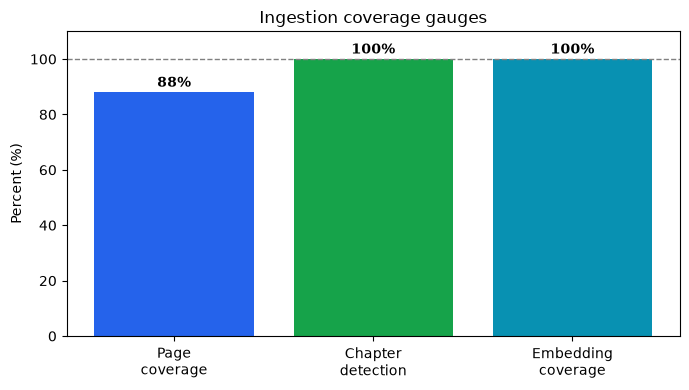

In [5]:

labels = ["Page\ncoverage", "Chapter\ndetection", "Embedding\ncoverage"]
vals = [page_coverage_pct, chapter_detection_pct, embedding_coverage_pct]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, vals, color=["#2563eb", "#16a34a", "#0891b2"])
ax.axhline(100, ls="--", lw=1, color="grey")
ax.set_ylim(0, 110)
ax.set_ylabel("Percent (%)")
ax.set_title("Ingestion coverage gauges")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 2, f"{v:.0f}%", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()


### D.2 Structural recall — ground truth vs. captured

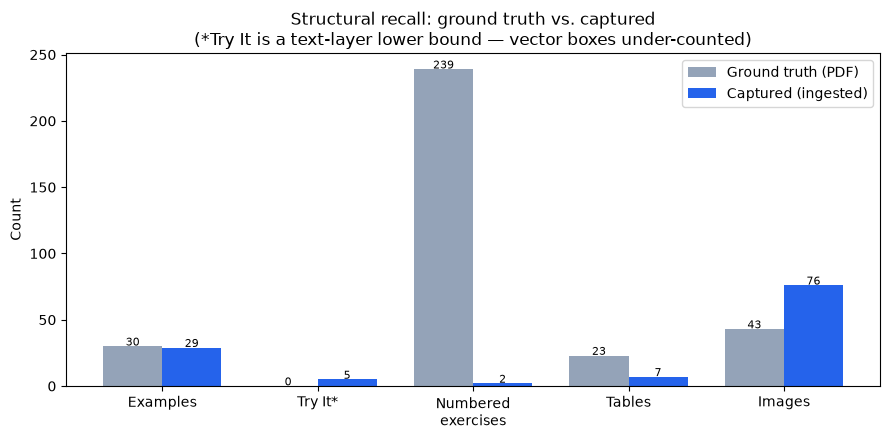

In [6]:

cats = ["Examples", "Try It*", "Numbered\nexercises", "Tables", "Images"]
gt_vals = [ground_truth["examples"], ground_truth["try_it_textlayer"],
           ground_truth["numbered_exercises"], ground_truth["detected_tables"],
           ground_truth["embedded_images"]]
cap_vals = [n_examples_mined, n_try_it_mined, n_homework_mined,
            table_idx, figure_idx]
x = range(len(cats))
fig, ax = plt.subplots(figsize=(9, 4.5))
w = 0.38
ax.bar([i - w/2 for i in x], gt_vals, width=w, label="Ground truth (PDF)", color="#94a3b8")
ax.bar([i + w/2 for i in x], cap_vals, width=w, label="Captured (ingested)", color="#2563eb")
ax.set_xticks(list(x)); ax.set_xticklabels(cats)
ax.set_ylabel("Count")
ax.set_title("Structural recall: ground truth vs. captured\n(*Try It is a text-layer lower bound — vector boxes under-counted)")
ax.legend()
for i, (g, c) in enumerate(zip(gt_vals, cap_vals)):
    ax.text(i - w/2, g + 0.5, str(g), ha="center", fontsize=8)
    ax.text(i + w/2, c + 0.5, str(c), ha="center", fontsize=8)
plt.tight_layout(); plt.show()


### D.3 Content-type capture rates

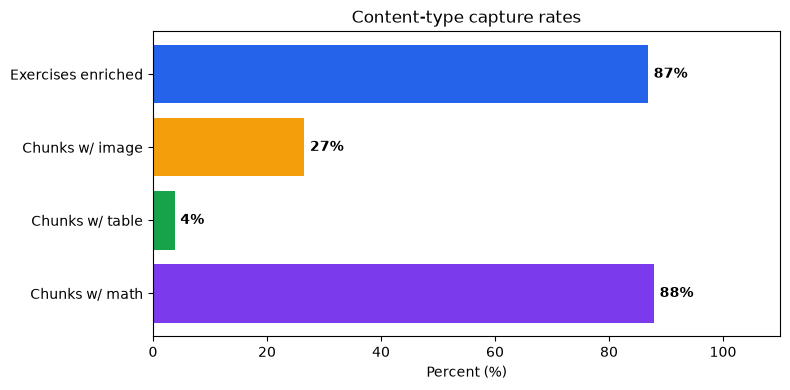

In [7]:

# Share of chunks carrying each content type + share of exercises enriched.
labels = ["Chunks w/ math", "Chunks w/ table", "Chunks w/ image", "Exercises enriched"]
vals = [
    pct(n_chunks_math, n_chunks),
    pct(n_chunks_table, n_chunks),
    pct(n_chunks_image, n_chunks),
    (enrichment_pct if enrichment_pct is not None else 0.0),
]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(labels, vals, color=["#7c3aed", "#16a34a", "#f59e0b", "#2563eb"])
ax.set_xlim(0, 110); ax.set_xlabel("Percent (%)")
ax.set_title("Content-type capture rates")
for b, v in zip(bars, vals):
    ax.text(v + 1, b.get_y() + b.get_height()/2, f"{v:.0f}%", va="center", fontweight="bold")
plt.tight_layout(); plt.show()


### D.4 Generated-question distributions (difficulty & chapter)

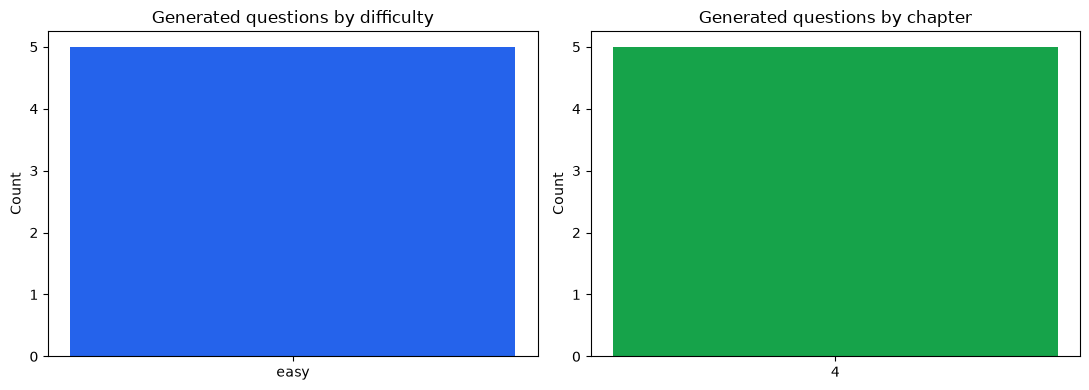

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Difficulty
diff_order = ["easy", "medium", "hard", "unknown"]
diff_items = [(d, q_diff.get(d, 0)) for d in diff_order if q_diff.get(d, 0)]
if not diff_items:
    diff_items = list(q_diff.items()) or [("(no questions yet)", 0)]
axes[0].bar([d for d, _ in diff_items], [c for _, c in diff_items], color="#2563eb")
axes[0].set_title("Generated questions by difficulty")
axes[0].set_ylabel("Count")

# Chapter
chap_items = sorted(((str(k), v) for k, v in q_chap.items()), key=lambda t: t[0])
if not chap_items:
    chap_items = [("(no questions yet)", 0)]
axes[1].bar([c for c, _ in chap_items], [v for _, v in chap_items], color="#16a34a")
axes[1].set_title("Generated questions by chapter")
axes[1].set_ylabel("Count")
plt.tight_layout(); plt.show()


## E. Ingestion Accuracy Scorecard

In [9]:

def fmt(v):
    return "N/A" if v is None else f"{v:.1f}%"

ingest_pct = meta.get("counts", {})
print("=" * 60)
print(" INGESTION ACCURACY SCORECARD —", meta.get("book_id", "Test_ch4-5"))
print("=" * 60)
print(f" PDF pages (ground truth)        : {ground_truth['pages']}")
print(f" Chunks ingested                 : {n_chunks}")
print(f" Chapters detected               : {chapters_detected}  (expected {EXPECTED_CHAPTERS})")
print("-" * 60)
print(f" Page coverage                   : {fmt(page_coverage_pct)}  ({n_pages_covered}/{ground_truth['pages']} pages)")
print(f" Chapter detection               : {fmt(chapter_detection_pct)}")
print(f" Embedding coverage              : {fmt(embedding_coverage_pct)}  ({n_emb}/{n_chunks})")
print(f" Example recall                  : {fmt(example_recall_pct)}  ({n_examples_mined}/{ground_truth['examples']})")
print(f" Math-bearing chunk rate         : {fmt(math_chunk_rate_pct)}  ({n_chunks_math}/{n_chunks})")
print("-" * 60)
print(" Estimates (not exactly grounded — see notes):")
print(f"   Try-It recall (EST)           : {fmt(try_it_recall_pct)}  ({n_try_it_mined}/{ground_truth['try_it_textlayer']} text-layer)")
print(f"   Numbered-exercise capture(EST): {fmt(exercise_capture_pct)}  ({n_homework_mined}/{ground_truth['numbered_exercises']})")
print(f"   Table capture (EST)           : {fmt(table_capture_pct)}  ({table_idx}/{ground_truth['detected_tables']})")
print(f"   Figure capture (EST)          : {fmt(figure_capture_pct)}  ({figure_idx}/{ground_truth['embedded_images']})")
print(f"   Exercise enrichment (EST)     : {fmt(enrichment_pct)}")
print("-" * 60)
print(f" Index sizes  math={ingested['math_index']}  table={ingested['table_index']}  figure={ingested['figure_index']}")
print(f" Exercises mined: example={n_examples_mined} try_it={n_try_it_mined} homework={n_homework_mined}")
print("=" * 60)

partial = (n_chunks == 0) or (math_idx == 0 and table_idx == 0 and figure_idx == 0) \
          or (len(exercises) == 0 and n_chunks > 0)
if partial:
    print("\n NOTE: Some collections are empty — ingestion appears PARTIAL.")
    print(" Re-run scripts/export_ingestion_metrics.py + this notebook after it completes.")


 INGESTION ACCURACY SCORECARD — Test_ch4-5
 PDF pages (ground truth)        : 75
 Chunks ingested                 : 132
 Chapters detected               : [4, 5]  (expected [4, 5])
------------------------------------------------------------
 Page coverage                   : 88.0%  (66/75 pages)
 Chapter detection               : 100.0%
 Embedding coverage              : 100.0%  (132/132)
 Example recall                  : 96.7%  (29/30)
 Math-bearing chunk rate         : 87.9%  (116/132)
------------------------------------------------------------
 Estimates (not exactly grounded — see notes):
   Try-It recall (EST)           : N/A  (5/0 text-layer)
   Numbered-exercise capture(EST): 0.8%  (2/239)
   Table capture (EST)           : 30.4%  (7/23)
   Figure capture (EST)          : 176.7%  (76/43)
   Exercise enrichment (EST)     : 86.8%
------------------------------------------------------------
 Index sizes  math=286  table=7  figure=76
 Exercises mined: example=29 try_it=5 homework

---
### Interpretation notes

* **Exact** metrics (page coverage, chapter detection, embedding coverage,
  example recall, math-chunk rate, exercise enrichment) are grounded directly
  against the PDF text layer or against complete in-DB counts.
* **Estimates** (`_EST`): *Try-It recall* and *numbered-exercise capture* compare
  against **text-layer** counts, which under-represent OpenStax vector-drawn boxes;
  *table/figure capture* compares index entries against PyMuPDF detections, which
  the indexer may legitimately merge or dedupe. Read these as directional.
* To refresh: `backend/.venv-test/bin/python scripts/export_ingestion_metrics.py`
  then re-run this notebook.
